In [13]:
from src.OrganoidMesh import OrganoidMesh
from src.mesh_analysis import *
from src.nonlocal_correlations import *
from src.cell_graph_functions import *
from src.utils import *
from src.organoid_plotting import *

In [14]:
# === New minimal helpers (no 'typing') ===
import os, glob
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# --- 1) Per-node HKS preprocessing (simple, stable) ---
def preprocess_hks_nodes(H, standardize_timescales=True, node_norm="l2"):
    """
    H: (n_cells, n_timescales)
    standardize_timescales: z-score each column within an organoid
    node_norm: 'l2' or None; per-node normalization to reduce scale effects
    """
    X = H.astype(float).copy()
    if standardize_timescales:
        mu = X.mean(axis=0, keepdims=True)
        sd = X.std(axis=0, keepdims=True) + 1e-12
        X = (X - mu) / sd
    if node_norm == "l2":
        nrm = np.linalg.norm(X, axis=1, keepdims=True) + 1e-12
        X = X / nrm
    return X

# --- 2) Pool nodes (balanced) and train a codebook ---
def train_codebook(global_feats_list, n_words, max_nodes_per_organoid=500, seed=0):
    """
    global_feats_list: list of (n_i, D) arrays (already preprocessed)
    Returns a fitted KMeans instance.
    """
    rng = np.random.default_rng(seed)
    pooled = []
    for F in global_feats_list:
        n = F.shape[0]
        if n <= max_nodes_per_organoid:
            pooled.append(F)
        else:
            idx = rng.choice(n, size=max_nodes_per_organoid, replace=False)
            pooled.append(F[idx])
    pool = np.vstack(pooled)
    kmeans = KMeans(n_clusters=n_words, random_state=seed, n_init="auto")
    kmeans.fit(pool)
    return kmeans

# --- 3) Encode an organoid as BoF histogram ---
def assign_codewords(F, kmeans):
    """F: (n_cells, D) preprocessed; returns (n_cells,) integer labels."""
    return kmeans.predict(F)

def bof_histogram(labels, k):
    """L1-normalized histogram; shape (k,)."""
    hist = np.bincount(labels, minlength=k).astype(float)
    s = hist.sum() + 1e-12
    return hist / s

# --- 4) Simple 2D embedding and plot ---
def embed_pca(X, n_components=2, seed=0):
    return PCA(n_components=n_components, random_state=seed).fit_transform(X)

def plot_bof_embedding(Z, color=None, title="Organoids (BoF, PCA)"):
    plt.figure(figsize=(6,5))
    if color is None:
        plt.scatter(Z[:,0], Z[:,1], s=30, alpha=0.85)
    else:
        sc = plt.scatter(Z[:,0], Z[:,1], s=30, alpha=0.85, c=color, cmap="viridis")
        cbar = plt.colorbar(sc)
        cbar.set_label("complexity")
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.title(title)
    plt.tight_layout()
    plt.show()


In [15]:
# === New imports (if not already present) ===
import numpy as np
import networkx as nx
from sklearn.cluster import KMeans
import pandas as pd
import os, glob
from tqdm import tqdm

# -----------------------------------------
# Load complexity scores from tsne_results.csv
# -----------------------------------------
tsne_df = pd.read_csv("../NicoleData/tsne_results.csv")
complexity_dict = dict(zip(tsne_df["label_uid"], tsne_df["complexity"]))
print(f"Loaded {len(complexity_dict)} complexity scores")

# Base directory for preprocessed data
preproc_base = os.path.join('..', 'NicoleData', 'preprocessed')

# --- Discover available timepoints dynamically ---
timepoints = sorted(
    [d for d in os.listdir(preproc_base) if os.path.isdir(os.path.join(preproc_base, d))]
)
print(f"Found {len(timepoints)} timepoints: {timepoints}")

# --- Initialize container ---
results = {}

# === Codebook params ===
t_HKS = np.array([1.0, 2.0, 4.0, 8.0, 25.0])   # must match columns of fields_cell
n_words = 8                                     # size of bag-of-features

# === Global accumulators for the codebook (features from ALL organoids) ===
_global_feats = []           # list of (N_i, D) arrays (preprocessed per organoid)
_global_refs  = []           # list of (tp, local_idx) so we can map back if needed

# === INTEGRATE inside your existing per-timepoint loop ===
for tp in timepoints:
    print(f"\n=== Processing timepoint: {tp} ===")

    tp_dir = os.path.join(preproc_base, tp)
    npz_files = sorted(glob.glob(os.path.join(tp_dir, "*.npz")))
    if not npz_files:
        print(f"  ⚠ No .npz files found for {tp}, skipping.")
        continue

    # Per-timepoint containers
    graphs_list = []
    feats_list = []

    HKS_list = []
    markers_list = []
    num_cells_list = []
    total_area_list = []
    total_volume_list = []
    complexity_list = []
    label_uid_list = []
    centroids_list = []

    for fpath in tqdm(npz_files, desc=f"{tp}"):
        try:
            data = np.load(fpath, allow_pickle=True)
        except Exception as e:
            print(f"Could not load {fpath}: {e}")
            continue

        try:
            # --- Basic data ---
            HKS_cell = data["fields_cell"]            # (n_cells, n_fields) e.g., HKS at t_HKS
            markers_cell = data["markers_cell"]
            cell_areas = data["cell_areas"]
            marker_names = list(data["marker_names"])
            cell_graph = load_cell_graph_from_npz(data)   # uses in-memory `data`
            num_cells = len(cell_areas)
            total_area = np.sum(data["vertex_areas"])
            total_volume = float(data["volume"])
            centroids = data['centroids']

            # --- Complexity / IDs ---
            well = str(data["well"])
            organoid_id = str(data["organoid_id"])
            label_uid = f"{tp}_{well}_{organoid_id}"
            complexity_value = complexity_dict.get(label_uid, np.nan)

            # --- Per-organoid node features for BoF ---
            feats = preprocess_hks_nodes(
                HKS_cell,                   # from fields_cell
                standardize_timescales=True,
                node_norm="l2"
            )

            # --- Store raw & derived ---
            graphs_list.append(cell_graph)
            feats_list.append(feats)

            HKS_list.append(HKS_cell)
            markers_list.append(markers_cell)
            num_cells_list.append(num_cells)
            total_area_list.append(total_area)
            total_volume_list.append(total_volume)
            complexity_list.append(complexity_value)
            label_uid_list.append(label_uid)
            centroids_list.append(centroids)

            # Accumulate globally for the shared codebook
            _global_feats.append(feats)                       # <-- now defined
            _global_refs.append((tp, len(HKS_list)-1))        # map back to this timepoint & index

        except Exception as e:
            print(f"Error analyzing {fpath}: {e}")
            continue

    # Keep per-timepoint bundles in `results`
    results[tp] = {
        "graphs_all": np.array(graphs_list, dtype=object),     # NEW
        "feats_all":  np.array(feats_list, dtype=object),      # NEW (preprocessed HKS per organoid)

        "HKS_all": np.array(HKS_list, dtype=object),
        "markers_all": np.array(markers_list, dtype=object),
        "num_cells": np.array(num_cells_list),
        "total_area": np.array(total_area_list),
        "total_volume": np.array(total_volume_list),
        "complexity": np.array(complexity_list),
        "label_uid": np.array(label_uid_list),
        "marker_names": marker_names,
        "centroids_all": np.array(centroids_list, dtype=object),
    }

    print(f"Stored raw field data for {len(HKS_list)} organoids at {tp}")


Loaded 2668 complexity scores
Found 5 timepoints: ['day3', 'day3p5', 'day4', 'day4p5', 'day4p5-more']

=== Processing timepoint: day3 ===


day3: 100%|██████████| 472/472 [00:00<00:00, 925.72it/s]


Stored raw field data for 472 organoids at day3

=== Processing timepoint: day3p5 ===


day3p5: 100%|██████████| 312/312 [00:00<00:00, 641.11it/s]


Stored raw field data for 312 organoids at day3p5

=== Processing timepoint: day4 ===


...

Stored raw field data for 357 organoids at day4

=== Processing timepoint: day4p5 ===


day4p5: 100%|██████████| 109/109 [00:00<00:00, 321.35it/s]


Stored raw field data for 109 organoids at day4p5

=== Processing timepoint: day4p5-more ===


day4p5-more: 100%|██████████| 534/534 [00:00<00:00, 564.70it/s]

Stored raw field data for 534 organoids at day4p5-more



=== Training shared codebook on pooled node descriptors ===
BoF matrix shape: (1784, 8)  (n_organoids × n_words)


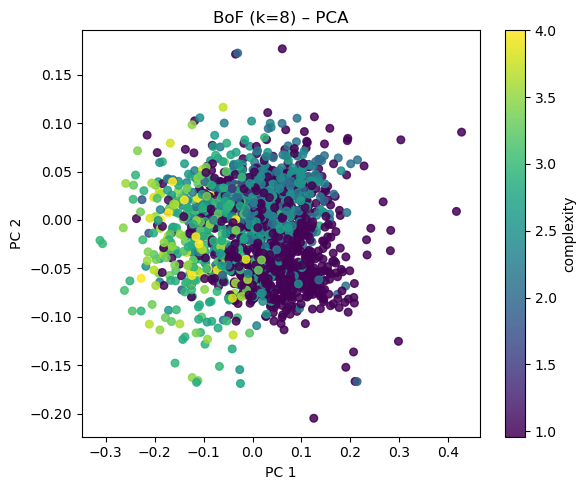

In [16]:
# --- Train a shared codebook on pooled nodes ---
print("\n=== Training shared codebook on pooled node descriptors ===")
kmeans = train_codebook(_global_feats, n_words, max_nodes_per_organoid=500, seed=42)

# --- Compute BoF per organoid and collect metadata for plotting ---
bof_list = []          # per organoid histogram (k,)
uid_list = []          # "tp_well_organoid"
complexity_all = []    # organoid-level complexity for coloring
tp_index_range = []    # to keep offsets per timepoint if needed later

for tp in timepoints:
    if tp not in results:
        continue
    feats_all = results[tp]["feats_all"]   # list of (n_cells, D)
    uids = results[tp]["label_uid"]
    cmplx = results[tp]["complexity"]

    start_idx = len(bof_list)
    for i, F in enumerate(feats_all):
        lbls = assign_codewords(F, kmeans)
        hist = bof_histogram(lbls, kmeans.n_clusters)
        bof_list.append(hist)
        uid_list.append(uids[i])
        complexity_all.append(cmplx[i])
    tp_index_range.append((tp, start_idx, len(bof_list)))

# Stack BoF matrix
X_bof = np.vstack(bof_list)          # shape (N_organoids, n_words)
complexity_all = np.array(complexity_all, dtype=float)

print(f"BoF matrix shape: {X_bof.shape}  (n_organoids × n_words)")

# --- 2D embedding and plot ---
Z = embed_pca(X_bof, n_components=2, seed=42)
plot_bof_embedding(Z, color=complexity_all, title=f"BoF (k={n_words}) – PCA")

# Optional: keep in a top-level dict for downstream use
bof_results = {
    "codebook": kmeans,          # contains .cluster_centers_
    "X_bof": X_bof,              # (N, k)
    "embedding_2d": Z,           # (N, 2)
    "label_uid": np.array(uid_list),
    "complexity": complexity_all,
    "n_words": n_words,
}


In [ ]:
# =========================
# Adaptive plotting block
# =========================
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import plotly.graph_objects as go
import plotly.colors as pc

# ---------- helpers ----------
def nearly_spherical_score(small_scale_hks):
    """
    Coefficient of variation of small-scale HKS; lower => more uniform (more spherical).
    """
    x = np.asarray(small_scale_hks)
    x = x[np.isfinite(x)]
    if x.size < 2:
        return 0.0
    mu = np.mean(x)
    sd = np.std(x)
    if mu == 0:
        return 0.0
    return float(sd / (abs(mu) + 1e-12))

def adaptive_kmeans(F, small_scale_hks,
                    k_max=3, seed=42,
                    sil_thresh=0.12,
                    min_frac=0.08,
                    cv_thresh=0.08):
    """
    Decide k in {1..k_max} per organoid. Returns (labels, k_chosen).
      - If near-spherical by HKS CV (cv_thresh), choose k=1.
      - Else try k=2..k_max; pick k with best silhouette if:
            silhouette >= sil_thresh AND all clusters >= min_frac of nodes.
      - Otherwise fall back to k=1.
    """
    n = F.shape[0]
    # Gate 1: spherical check
    cv = nearly_spherical_score(small_scale_hks)
    if cv < cv_thresh:
        return np.zeros(n, dtype=int), 1

    best_labels, best_sil, best_k = None, -1.0, None
    for k in range(2, k_max + 1):
        km = KMeans(n_clusters=k, n_init="auto", random_state=seed)
        labs = km.fit_predict(F)
        counts = np.bincount(labs, minlength=k)
        if (counts < max(1, int(min_frac * n))).any():
            continue
        try:
            s = silhouette_score(F, labs, metric="euclidean")
        except Exception:
            s = -1.0
        if s > best_sil:
            best_labels, best_sil, best_k = labs, s, k

    if best_k is None or best_sil < sil_thresh:
        return np.zeros(n, dtype=int), 1
    return best_labels, best_k

def label_segments_by_hks(regions, small_scale_hks):
    """
    Heuristic names using mean small-scale HKS:
      lowest -> neck-like, highest -> crypt-like, middle -> villus-like.
      If k=2: neck-like (low) and villus-like (high).
      If k=1: villus-like.
    """
    k = len(regions)
    if k == 1:
        return ["villus-like"]

    means = []
    for reg in regions:
        if len(reg) == 0:
            means.append(np.nan)
        else:
            means.append(float(np.nanmean(small_scale_hks[list(reg)])))
    order = np.argsort(means)  # ascending

    if k == 2:
        names = [None, None]
        names[order[0]] = "neck-like"
        names[order[1]] = "villus-like"
        return names

    # k >= 3
    names = [None] * k
    names[order[0]] = "neck-like"
    names[order[-1]] = "crypt-like"
    for idx in order[1:-1]:
        names[idx] = "villus-like"
    return names

# ---------- gather eligible organoids ----------
rng = np.random.default_rng(123)
org_index = []
for tp in timepoints:
    if tp not in results:
        continue
    graphs = results[tp].get("graphs_all", None)
    centrs = results[tp].get("centroids_all", None)
    feats  = results[tp].get("feats_all", None)
    hks    = results[tp].get("HKS_all", None)
    if graphs is None or centrs is None or feats is None or hks is None:
        continue

    n_org = len(feats)
    for i in range(n_org):
        G = graphs[i]
        C = centrs[i]
        F = feats[i]
        H = hks[i]
        if G is None or C is None or F is None or H is None:
            continue
        # Size consistency checks
        n_nodes = F.shape[0]
        if (len(G) == n_nodes and
            hasattr(C, "shape") and C.shape[0] == n_nodes and
            H.shape[0] == n_nodes):
            org_index.append((tp, i))

if len(org_index) == 0:
    print("No organoids available for plotting.")
else:
    # choose up to 5 unique organoids at random
    pick = rng.choice(len(org_index), size=min(5, len(org_index)), replace=False)

    # palettes
    pal2 = ["#e41a1c", "#377eb8"]               # neck, villus
    pal3 = ["#e41a1c", "#377eb8", "#4daf4a"]    # neck, villus, crypt

    for j, sel in enumerate(pick, start=1):
        tp, idx = org_index[sel]
        G = results[tp]["graphs_all"][idx]
        C = results[tp]["centroids_all"][idx]
        F = results[tp]["feats_all"][idx]         # (n_cells, D) preprocessed HKS
        H = results[tp]["HKS_all"][idx]           # (n_cells, T) raw HKS
        uid = results[tp]["label_uid"][idx]
        cmplx = results[tp]["complexity"][idx]

        # base scalar field for node coloring = small-scale HKS
        small_scale = H[:, 0] if (H.ndim == 2 and H.shape[1] >= 1) else F[:, 0]

        # --- adaptive segmentation (k in {1,2,3})
        seg_labels, k_chosen = adaptive_kmeans(
            F, small_scale_hks=small_scale,
            k_max=3, seed=42,
            sil_thresh=0.01,    # raise to be stricter
            min_frac=0.02,      # min cluster size as fraction of nodes
            cv_thresh=0.05      # uniformity gate; raise for more k=1 calls
        )

        # Build regions as sets of node indices
        regions = []
        for seg_id in range(k_chosen):
            nodes_in_seg = np.where(seg_labels == seg_id)[0]
            regions.append(set(nodes_in_seg.tolist()))

        # Heuristic names
        names = label_segments_by_hks(regions, small_scale)

        # Plot main graph: nodes colored by small-scale HKS
        fig = plot_organoid_graph(
            centroids=C,
            graph=G,
            node_values=small_scale,
            node_size=4,
            edge_width=0.8,
            colorscale="RdBu_r",
            center_at_zero=True,
            loops=None,
        )

        # Choose overlay colors based on k
        palette = pal3 if k_chosen >= 3 else (pal2 if k_chosen == 2 else ["#377eb8"])

        # Add overlays
        add_region_overlays(
            fig,
            coords=C,
            regions=regions,
            colors=palette,
            colorscale=None,
            size=6.5,
            name_prefix="",
            alpha=0.35,
        )

        # Name the overlay traces in the legend
        # (last added traces correspond to overlays, in order)
        for t, nm in zip(fig.data[-len(regions):], names):
            t.name = nm

        title_suffix = " (uniform → all villus)" if k_chosen == 1 else f" (k={k_chosen})"
        try:
            cmplx_val = float(cmplx)
            cmplx_txt = f"{cmplx_val:.3f}" if np.isfinite(cmplx_val) else "nan"
        except Exception:
            cmplx_txt = "nan"

        fig.update_layout(
            title=f"Organoid {uid} @ {tp} — complexity={cmplx_txt}{title_suffix}",
            legend=dict(itemsizing="constant"),
        )
        fig.show()
